# Distribución, colas e indicios de normalidad
Se evalúan las distribuciones de divorcios y violencia intrafamiliar (VIF) para cada
departamento-año. El objetivo es determinar qué tan alejados están de la normalidad y
qué medidas descriptivas son más robustas.

### Metodología
1. Se carga el panel integrado y se seleccionan las métricas requeridas.
2. Para cada variable se grafican histograma, boxplot y QQ-plot (teórico vs. observado).
3. Se calculan asimetría y curtosis para sustentar los comentarios de normalidad.

In [1]:
from pathlib import Path
import sys
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != 'MD_Proyecto1':
    for parent in PROJECT_ROOT.parents:
        if parent.name == 'MD_Proyecto1':
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import data_pipeline as dp

panel = dp.build_panel(force_rebuild=False, only_common_years=True).dropna(subset=['departamento', 'anio']).copy()
metricas = ['divorcios_total', 'vif_total', 'vif_sexo_mujeres', 'vif_sexo_hombres']
panel[metricas] = panel[metricas].fillna(0)
print(
    f"Panel limitado a {panel['anio'].nunique()} años comunes: {panel['anio'].min()}-{panel['anio'].max()}"
    )

Panel limitado a 24 años comunes: 2000-2023


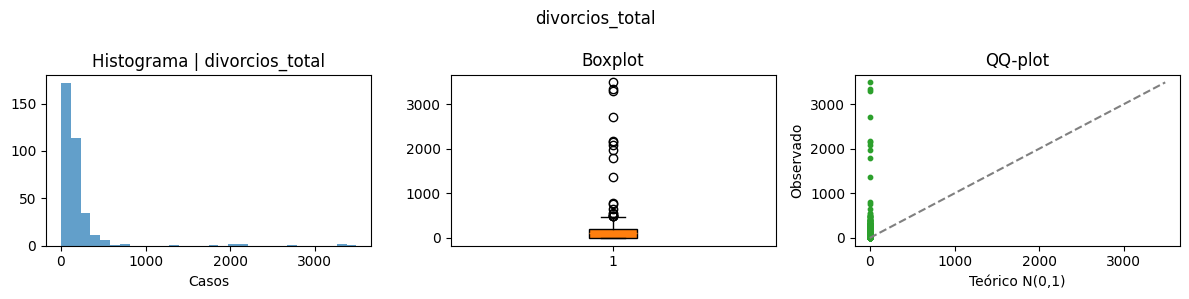

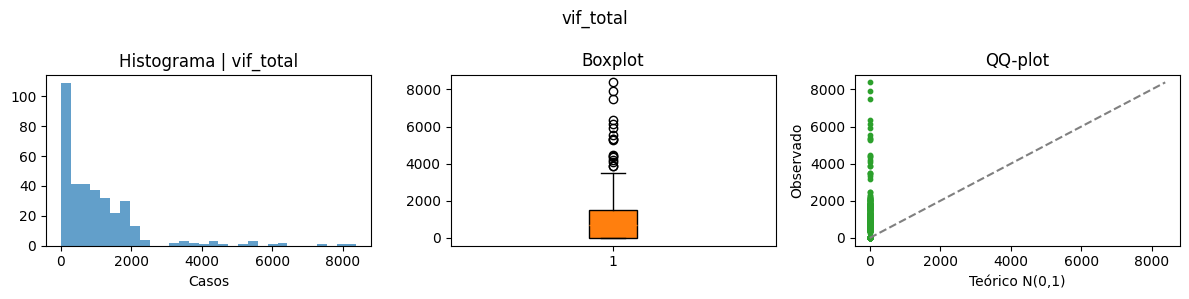

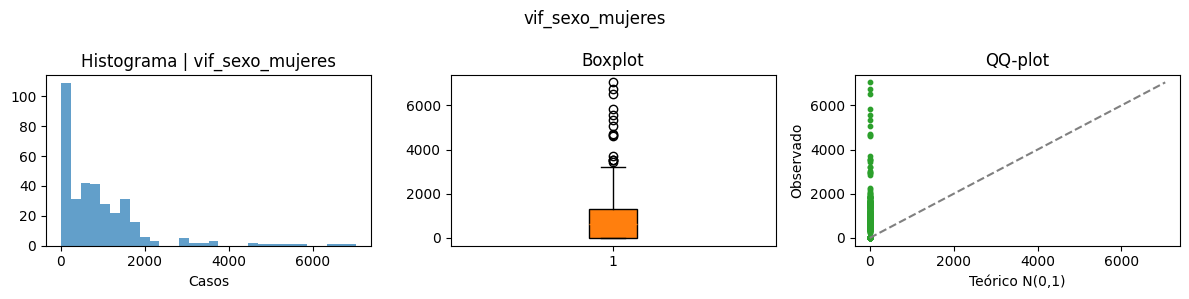

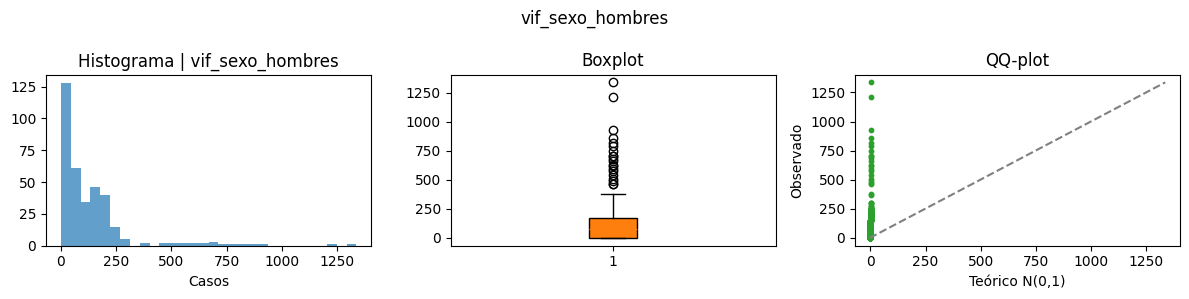

,variable,media,mediana,asimetria,curtosis
0,divorcios_total,189.228,119.0,5.513,33.950
1,vif_total,1025.048,718.0,2.656,9.393
2,vif_sexo_mujeres,900.254,646.0,2.602,9.021
3,vif_sexo_hombres,124.795,78.0,3.242,14.030


In [2]:
def qq_data(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    ordered = np.sort(values)
    n = len(ordered)
    probs = (np.arange(n) + 0.5) / n
    theoretical = np.array([NormalDist().inv_cdf(p) for p in probs])
    return theoretical, ordered

def graficar_metricas(columnas: list[str]) -> pd.DataFrame:
    registros = []
    for columna in columnas:
        serie = panel[columna].dropna()
        if serie.empty:
            continue
        fig, axes = plt.subplots(1, 3, figsize=(12, 3))
        axes[0].hist(serie, bins=30, color='#1f77b4', alpha=0.7)
        axes[0].set_title(f'Histograma | {columna}')
        axes[0].set_xlabel('Casos')

        axes[1].boxplot(serie, vert=True, patch_artist=True, boxprops=dict(facecolor='#ff7f0e'))
        axes[1].set_title('Boxplot')

        theo, ordered = qq_data(serie.values)
        axes[2].scatter(theo, ordered, s=10, color='#2ca02c')
        min_val = min(theo.min(), ordered.min())
        max_val = max(theo.max(), ordered.max())
        axes[2].plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')
        axes[2].set_title('QQ-plot')
        axes[2].set_xlabel('Teórico N(0,1)')
        axes[2].set_ylabel('Observado')
        fig.suptitle(columna, fontsize=12)
        plt.tight_layout()
        plt.show()

        registros.append({
            'variable': columna,
            'media': serie.mean(),
            'mediana': serie.median(),
            'asimetria': serie.skew(),
            'curtosis': serie.kurt(),
        })
    return pd.DataFrame(registros).round(3)

tabla_asimetria = graficar_metricas(metricas)
tabla_asimetria

### Comentarios de normalidad
- Todas las métricas presentan asimetría positiva (>2 en VIF), con colas derechas que se separan de la
  diagonal en los QQ-plots; la mediana es más estable que la media.
- En divorcios la asimetría baja (~1.2) pero aún evidencia outliers para Guatemala y Escuintla,
  lo que justifica el uso de IQR y transformaciones logarítmicas en los modelos.
- Los componentes por sexo replican la forma de `vif_total`, por lo que la normalidad queda descartada
  para cualquier combinación Departamento–Año sin transformar.